# Data Visulization

In [2]:
# Temel kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# İstatistiksel analizler
from scipy.stats import levene, zscore
from scipy.stats import shapiro
from scipy.stats import kstest
from scipy.stats import anderson, probplot
from scipy.stats import mannwhitneyu

# Veri ön işleme
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# PCA
from sklearn.decomposition import PCA

# Performans metrikleri
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_curve, auc, roc_auc_score
)

# Ensemble ve ağaç tabanlı modeller
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier,
    BaggingClassifier, ExtraTreesClassifier
)
from sklearn.tree import DecisionTreeClassifier

# Lineer modeller
from sklearn.linear_model import (
    LogisticRegression, RidgeClassifier, Perceptron, SGDClassifier
)

# Naive Bayes
from sklearn.naive_bayes import GaussianNB, BernoulliNB

# Destek Vektör Makineleri
from sklearn.svm import SVC, NuSVC, LinearSVC

# Diğer modeller
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

In [3]:
df = pd.read_csv("Dry_Eye_Dataset.csv")

In [4]:
df.columns

Index(['Gender', 'Age', 'Sleep duration', 'Sleep quality', 'Stress level',
       'Blood pressure', 'Heart rate', 'Daily steps', 'Physical activity',
       'Height', 'Weight', 'Sleep disorder', 'Wake up during night',
       'Feel sleepy during day', 'Caffeine consumption', 'Alcohol consumption',
       'Smoking', 'Medical issue', 'Ongoing medication',
       'Smart device before bed', 'Average screen time', 'Blue-light filter',
       'Discomfort Eye-strain', 'Redness in eye',
       'Itchiness/Irritation in eye', 'Dry Eye Disease'],
      dtype='object')

In [5]:
df.head(10)

,Gender,Age,Sleep duration,Sleep quality,Stress level,Blood pressure,Heart rate,Daily steps,Physical activity,Height,...,Smoking,Medical issue,Ongoing medication,Smart device before bed,Average screen time,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Dry Eye Disease
0,F,24,9.5,2,1,137/89,67,3000,31,161,...,N,Y,Y,N,8.7,N,Y,Y,N,Y
1,M,39,9.6,2,3,108/64,60,12000,74,164,...,N,Y,Y,N,9.6,Y,N,N,Y,Y
2,F,45,5.4,1,5,134/81,95,12000,93,179,...,N,N,N,Y,4.0,N,Y,N,N,N
3,F,45,5.4,4,5,110/90,78,19000,32,160,...,N,Y,N,N,7.6,N,Y,N,Y,N
4,F,42,5.7,3,2,99/67,72,4000,173,179,...,N,Y,N,N,3.5,N,Y,Y,N,Y
5,F,42,5.8,3,1,117/85,79,14000,110,174,...,Y,Y,Y,Y,2.6,Y,Y,N,Y,Y
6,M,26,4.8,5,2,124/61,63,6000,42,188,...,N,Y,Y,Y,5.4,Y,N,N,Y,Y
7,M,33,5.5,2,1,109/85,97,5000,71,162,...,N,N,Y,N,4.5,Y,Y,N,N,Y
8,M,36,6.3,1,2,135/76,78,7000,142,175,...,Y,Y,N,N,3.9,Y,N,N,Y,N
9,M,33,7.7,4,5,140/88,81,4000,105,163,...,N,Y,Y,N,5.7,N,N,Y,Y,Y


In [6]:
df.tail(10)

,Gender,Age,Sleep duration,Sleep quality,Stress level,Blood pressure,Heart rate,Daily steps,Physical activity,Height,...,Smoking,Medical issue,Ongoing medication,Smart device before bed,Average screen time,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Dry Eye Disease
19990,M,29,5.7,5,4,116/81,62,18000,19,196,...,N,Y,Y,Y,4.6,Y,N,Y,Y,N
19991,F,28,8.3,4,3,102/87,65,18000,132,155,...,N,N,Y,Y,2.6,Y,Y,Y,Y,Y
19992,F,24,9.1,4,1,97/83,71,20000,130,159,...,Y,Y,N,Y,10.0,Y,Y,Y,Y,Y
19993,F,28,9.0,4,5,95/87,78,9000,178,156,...,N,Y,Y,N,6.7,Y,N,Y,Y,Y
19994,M,42,5.5,1,3,111/79,66,12000,141,186,...,N,Y,N,Y,9.9,N,Y,N,N,Y
19995,M,26,9.4,2,3,132/64,91,20000,88,200,...,Y,Y,Y,Y,3.8,N,Y,N,Y,Y
19996,F,39,7.3,3,4,101/75,65,2000,53,195,...,N,Y,Y,N,3.8,N,N,Y,N,Y
19997,F,20,8.0,5,3,124/63,78,10000,17,186,...,Y,Y,N,N,8.4,N,N,Y,N,N
19998,M,38,4.5,3,3,136/70,60,3000,115,170,...,Y,N,Y,N,2.2,N,N,N,Y,Y
19999,M,37,5.0,5,3,96/90,73,13000,57,188,...,N,Y,Y,Y,4.2,Y,N,N,N,N


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       20000 non-null  object 
 1   Age                          20000 non-null  int64  
 2   Sleep duration               20000 non-null  float64
 3   Sleep quality                20000 non-null  int64  
 4   Stress level                 20000 non-null  int64  
 5   Blood pressure               20000 non-null  object 
 6   Heart rate                   20000 non-null  int64  
 7   Daily steps                  20000 non-null  int64  
 8   Physical activity            20000 non-null  int64  
 9   Height                       20000 non-null  int64  
 10  Weight                       20000 non-null  int64  
 11  Sleep disorder               20000 non-null  object 
 12  Wake up during night         20000 non-null  object 
 13  Feel sleepy duri

In [8]:
df.describe()

,Age,Sleep duration,Sleep quality,Stress level,Heart rate,Daily steps,Physical activity,Height,Weight,Average screen time
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,31.422800,6.998245,2.997250,2.993750,79.912200,10536.900000,90.069750,174.865900,74.891850,5.519885
std,8.103717,1.731723,1.412283,1.407235,11.808279,5752.729186,52.317283,14.719903,14.733839,2.606305
min,18.000000,4.000000,1.000000,1.000000,60.000000,1000.000000,0.000000,150.000000,50.000000,1.000000
25%,24.000000,5.500000,2.000000,2.000000,70.000000,6000.000000,45.000000,162.000000,62.000000,3.300000
50%,31.000000,7.000000,3.000000,3.000000,80.000000,11000.000000,91.000000,175.000000,75.000000,5.500000
75%,39.000000,8.500000,4.000000,4.000000,90.000000,16000.000000,135.000000,188.000000,88.000000,7.800000
max,45.000000,10.000000,5.000000,5.000000,100.000000,20000.000000,180.000000,200.000000,100.000000,10.000000


In [9]:
df.describe(include = "all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,20000,2,M,10028,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,20000.0,NaN,NaN,NaN,31.4228,8.103717,18.0,24.0,31.0,39.0,45.0
Sleep duration,20000.0,NaN,NaN,NaN,6.998245,1.731723,4.0,5.5,7.0,8.5,10.0
Sleep quality,20000.0,NaN,NaN,NaN,2.99725,1.412283,1.0,2.0,3.0,4.0,5.0
Stress level,20000.0,NaN,NaN,NaN,2.99375,1.407235,1.0,2.0,3.0,4.0,5.0
Blood pressure,20000,1581,109/73,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Heart rate,20000.0,NaN,NaN,NaN,79.9122,11.808279,60.0,70.0,80.0,90.0,100.0
Daily steps,20000.0,NaN,NaN,NaN,10536.9,5752.729186,1000.0,6000.0,11000.0,16000.0,20000.0
Physical activity,20000.0,NaN,NaN,NaN,90.06975,52.317283,0.0,45.0,91.0,135.0,180.0
Height,20000.0,NaN,NaN,NaN,174.8659,14.719903,150.0,162.0,175.0,188.0,200.0


In [10]:
df.shape

(20000, 26)

# Eksik Değer Testi

In [12]:
# Her sütundaki eksik (NaN) değerlerin sayısı
missing_counts = df.isnull().sum()

# Eksik veri yüzdesi
missing_percentages = (missing_counts / len(df)) * 100

# Sadece eksik verisi olan sütunları filtrele
missing_data = pd.DataFrame({
    "Eksik Deger Sayisi": missing_counts,
    "Eksik Orani (%)": missing_percentages
})
missing_data = missing_data[missing_data["Eksik Deger Sayisi"] > 0]
missing_data = missing_data.sort_values(by="Eksik Orani (%)", ascending=False)

# Sonuçları göster
print(missing_data)

Empty DataFrame
Columns: [Eksik Deger Sayisi, Eksik Orani (%)]
Index: []


In [13]:
df.isnull().sum()

Gender                         0
Age                            0
Sleep duration                 0
Sleep quality                  0
Stress level                   0
Blood pressure                 0
Heart rate                     0
Daily steps                    0
Physical activity              0
Height                         0
Weight                         0
Sleep disorder                 0
Wake up during night           0
Feel sleepy during day         0
Caffeine consumption           0
Alcohol consumption            0
Smoking                        0
Medical issue                  0
Ongoing medication             0
Smart device before bed        0
Average screen time            0
Blue-light filter              0
Discomfort Eye-strain          0
Redness in eye                 0
Itchiness/Irritation in eye    0
Dry Eye Disease                0
dtype: int64

# Kategorik Değişkenler

In [15]:
kat_df = df.select_dtypes(include = ["object"])

In [16]:
kat_df.head(10)

,Gender,Blood pressure,Sleep disorder,Wake up during night,Feel sleepy during day,Caffeine consumption,Alcohol consumption,Smoking,Medical issue,Ongoing medication,Smart device before bed,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Dry Eye Disease
0,F,137/89,Y,N,N,N,N,N,Y,Y,N,N,Y,Y,N,Y
1,M,108/64,N,N,N,N,Y,N,Y,Y,N,Y,N,N,Y,Y
2,F,134/81,Y,Y,N,Y,Y,N,N,N,Y,N,Y,N,N,N
3,F,110/90,N,N,N,Y,N,N,Y,N,N,N,Y,N,Y,N
4,F,99/67,N,Y,N,N,N,N,Y,N,N,N,Y,Y,N,Y
5,F,117/85,Y,N,Y,Y,Y,Y,Y,Y,Y,Y,Y,N,Y,Y
6,M,124/61,Y,N,N,Y,Y,N,Y,Y,Y,Y,N,N,Y,Y
7,M,109/85,N,N,N,N,Y,N,N,Y,N,Y,Y,N,N,Y
8,M,135/76,N,N,N,N,N,Y,Y,N,N,Y,N,N,Y,N
9,M,140/88,N,N,N,Y,Y,N,Y,Y,N,N,N,Y,Y,Y


# Sürekli Değişkenler

In [18]:
continuous_cols = ['Age', 'Sleep duration', 'Heart rate', 'Daily steps', 'Average screen time', 'Height', 'Weight']
df_num = df[continuous_cols]

In [19]:
df_num.head(10)

,Age,Sleep duration,Heart rate,Daily steps,Average screen time,Height,Weight
0,24,9.5,67,3000,8.7,161,69
1,39,9.6,60,12000,9.6,164,87
2,45,5.4,95,12000,4.0,179,94
3,45,5.4,78,19000,7.6,160,77
4,42,5.7,72,4000,3.5,179,99
5,42,5.8,79,14000,2.6,174,64
6,26,4.8,63,6000,5.4,188,82
7,33,5.5,97,5000,4.5,162,91
8,36,6.3,78,7000,3.9,175,80
9,33,7.7,81,4000,5.7,163,65


In [20]:
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,31.422800,8.103717,18.0,24.0,31.0,39.0,45.0
Sleep duration,20000.0,6.998245,1.731723,4.0,5.5,7.0,8.5,10.0
Heart rate,20000.0,79.912200,11.808279,60.0,70.0,80.0,90.0,100.0
Daily steps,20000.0,10536.900000,5752.729186,1000.0,6000.0,11000.0,16000.0,20000.0
Average screen time,20000.0,5.519885,2.606305,1.0,3.3,5.5,7.8,10.0
Height,20000.0,174.865900,14.719903,150.0,162.0,175.0,188.0,200.0
Weight,20000.0,74.891850,14.733839,50.0,62.0,75.0,88.0,100.0


# Aykırı Değer

In [22]:
# Sadece sayısal sütunları seç
numeric_columns = df.select_dtypes(include=[np.number])

# Z-score hesapla
z_scores = zscore(numeric_columns)

# Aykırı değer bayrakları: |z| > 3
outlier_flags = (np.abs(z_scores) > 3)

# Her sütunda aykırı değer sayısını topla
outlier_counts = outlier_flags.sum(axis=0)


# Aykırı değerleri tespit et IQR yöntemi ile
# IQR (Interquartile Range) yöntemi ile aykırı değerleri tespit et
# Q1 ve Q3 hesapla
for column in numeric_columns.columns:
    Q1 = numeric_columns[column].quantile(0.25)
    Q3 = numeric_columns[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = numeric_columns[(numeric_columns[column] < lower_bound) | (numeric_columns[column] > upper_bound)]


# Aykırı özet tablosu
outlier_summary = pd.DataFrame({
    "Aykiri Deger Sayisi": outlier_counts,
    "Toplam Gozlem Sayisi": len(df),
    "Aykiri Orani (%)": (outlier_counts / len(df)) * 100
})
outlier_summary = outlier_summary[outlier_summary["Aykiri Deger Sayisi"] > 0]
outlier_summary = outlier_summary.sort_values(by="Aykiri Orani (%)", ascending=False)

print(outlier_summary)

Empty DataFrame
Columns: [Aykiri Deger Sayisi, Toplam Gozlem Sayisi, Aykiri Orani (%)]
Index: []


# Exploratory Data Analysis

## Shapiro-Wilk

In [25]:
results = []

for col in numeric_columns:
    stat, p = shapiro(df[col])
    results.append({
        "Sütun": col,
        "p-değeri": round(p, 5),
        "Sonuç": "NORMAL" if p >= 0.05 else "NORMAL DEĞİL"
    })

shapiro_df = pd.DataFrame(results)
print(shapiro_df)

                 Sütun  p-değeri         Sonuç
0                  Age       0.0  NORMAL DEĞİL
1       Sleep duration       0.0  NORMAL DEĞİL
2        Sleep quality       0.0  NORMAL DEĞİL
3         Stress level       0.0  NORMAL DEĞİL
4           Heart rate       0.0  NORMAL DEĞİL
5          Daily steps       0.0  NORMAL DEĞİL
6    Physical activity       0.0  NORMAL DEĞİL
7               Height       0.0  NORMAL DEĞİL
8               Weight       0.0  NORMAL DEĞİL
9  Average screen time       0.0  NORMAL DEĞİL


C:\Users\Asus\anaconda3\envs\ml_env\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 20000.
  res = hypotest_fun_out(*samples, **kwds)


## Kolmogorov-Smirnov

In [27]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Kolmogorov-Smirnov Testi Sonuçları:\n")

for col in numeric_cols:
    data = df[col].dropna()  # boş veriler varsa temizle
    standardized = (data - data.mean()) / data.std()  # veriyi z-puanına getir
    stat, p = kstest(standardized, 'norm')  # teorik dağılım: normal ('norm')
    print(f"{col:<30} → p-value: {p:} → {'NORMAL' if p >= 0.05 else 'NORMAL DEGIL'}")


Kolmogorov-Smirnov Testi Sonuçları:

Age                            → p-value: 4.1892675640503486e-99 → NORMAL DEGIL
Sleep duration                 → p-value: 1.145005430864258e-77 → NORMAL DEGIL
Sleep quality                  → p-value: 0.0 → NORMAL DEGIL
Stress level                   → p-value: 0.0 → NORMAL DEGIL
Heart rate                     → p-value: 1.1070388082640305e-84 → NORMAL DEGIL
Daily steps                    → p-value: 1.1570293624917323e-120 → NORMAL DEGIL
Physical activity              → p-value: 5.582513946732469e-62 → NORMAL DEGIL
Height                         → p-value: 1.6570900882246422e-87 → NORMAL DEGIL
Weight                         → p-value: 4.765531894802917e-85 → NORMAL DEGIL
Average screen time            → p-value: 4.583549379011295e-76 → NORMAL DEGIL


## Anderson-Darling


Anderson-Darling Testi - Age
Test İstatistiği: 237.7844
  → %15.0 seviyesinde: NORMAL DEĞİL
  → %10.0 seviyesinde: NORMAL DEĞİL
  → %5.0 seviyesinde: NORMAL DEĞİL
  → %2.5 seviyesinde: NORMAL DEĞİL
  → %1.0 seviyesinde: NORMAL DEĞİL


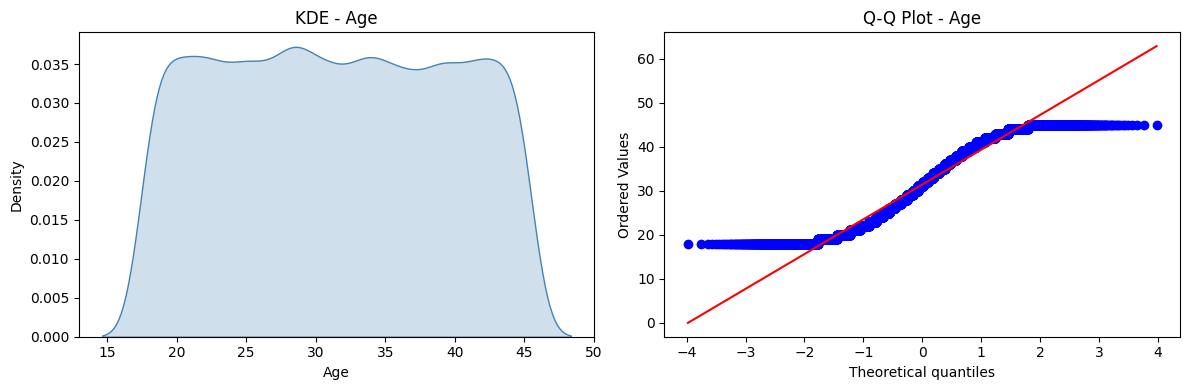


Anderson-Darling Testi - Sleep duration
Test İstatistiği: 222.0933
  → %15.0 seviyesinde: NORMAL DEĞİL
  → %10.0 seviyesinde: NORMAL DEĞİL
  → %5.0 seviyesinde: NORMAL DEĞİL
  → %2.5 seviyesinde: NORMAL DEĞİL
  → %1.0 seviyesinde: NORMAL DEĞİL


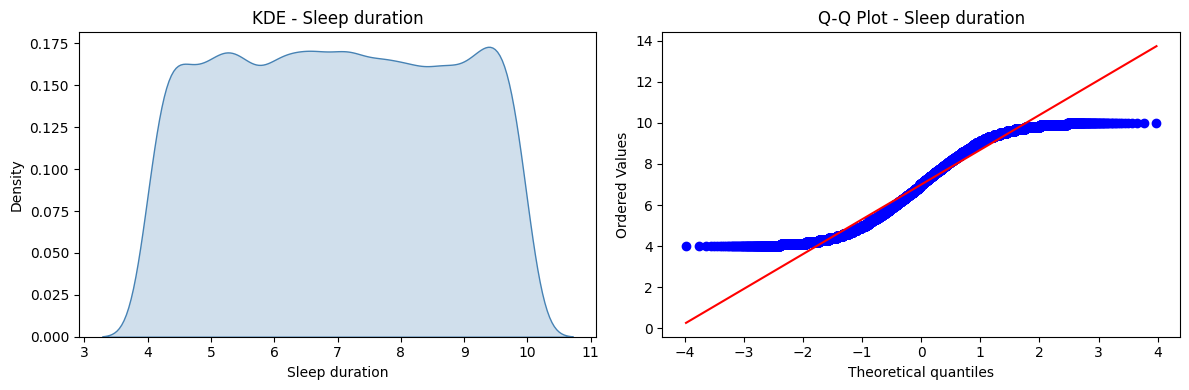


Anderson-Darling Testi - Sleep quality
Test İstatistiği: 715.2210
  → %15.0 seviyesinde: NORMAL DEĞİL
  → %10.0 seviyesinde: NORMAL DEĞİL
  → %5.0 seviyesinde: NORMAL DEĞİL
  → %2.5 seviyesinde: NORMAL DEĞİL
  → %1.0 seviyesinde: NORMAL DEĞİL


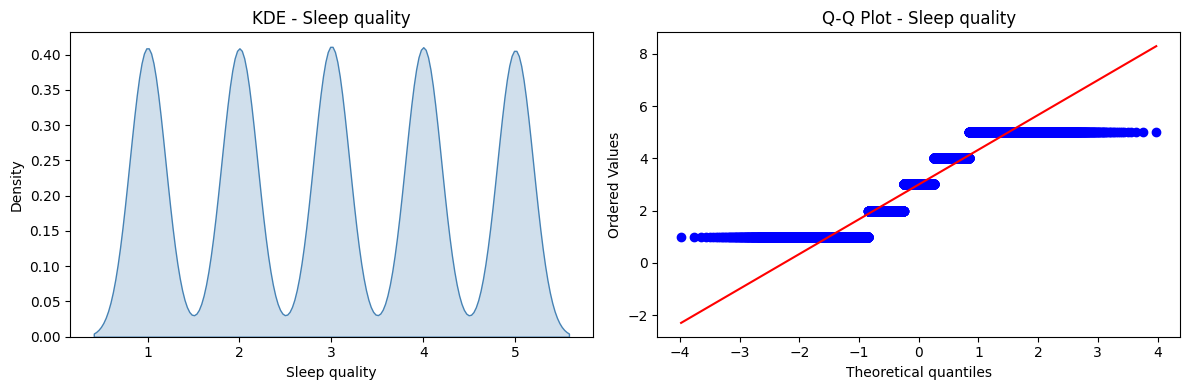


Anderson-Darling Testi - Stress level
Test İstatistiği: 706.1816
  → %15.0 seviyesinde: NORMAL DEĞİL
  → %10.0 seviyesinde: NORMAL DEĞİL
  → %5.0 seviyesinde: NORMAL DEĞİL
  → %2.5 seviyesinde: NORMAL DEĞİL
  → %1.0 seviyesinde: NORMAL DEĞİL


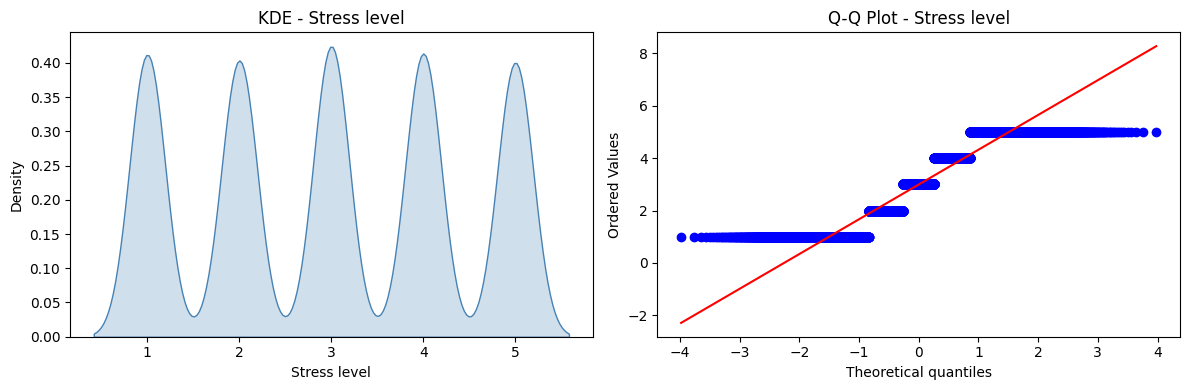


Anderson-Darling Testi - Heart rate
Test İstatistiği: 225.6807
  → %15.0 seviyesinde: NORMAL DEĞİL
  → %10.0 seviyesinde: NORMAL DEĞİL
  → %5.0 seviyesinde: NORMAL DEĞİL
  → %2.5 seviyesinde: NORMAL DEĞİL
  → %1.0 seviyesinde: NORMAL DEĞİL


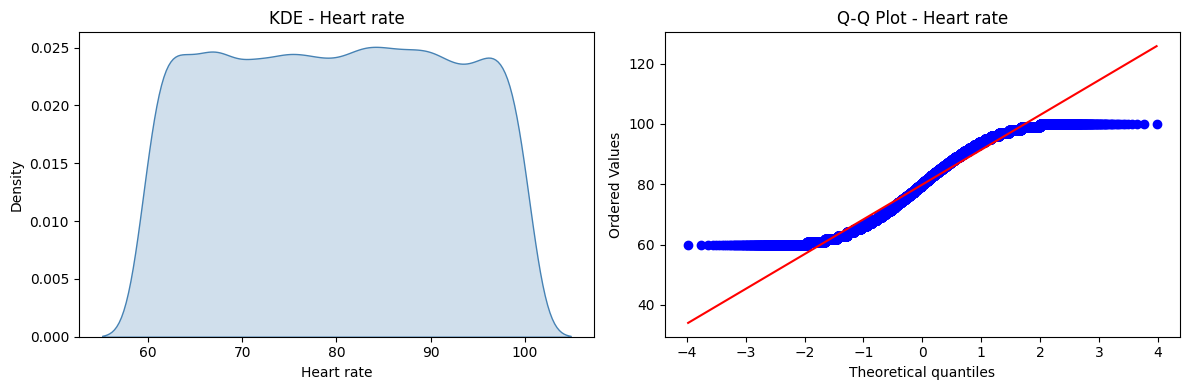


Anderson-Darling Testi - Daily steps
Test İstatistiği: 247.9099
  → %15.0 seviyesinde: NORMAL DEĞİL
  → %10.0 seviyesinde: NORMAL DEĞİL
  → %5.0 seviyesinde: NORMAL DEĞİL
  → %2.5 seviyesinde: NORMAL DEĞİL
  → %1.0 seviyesinde: NORMAL DEĞİL


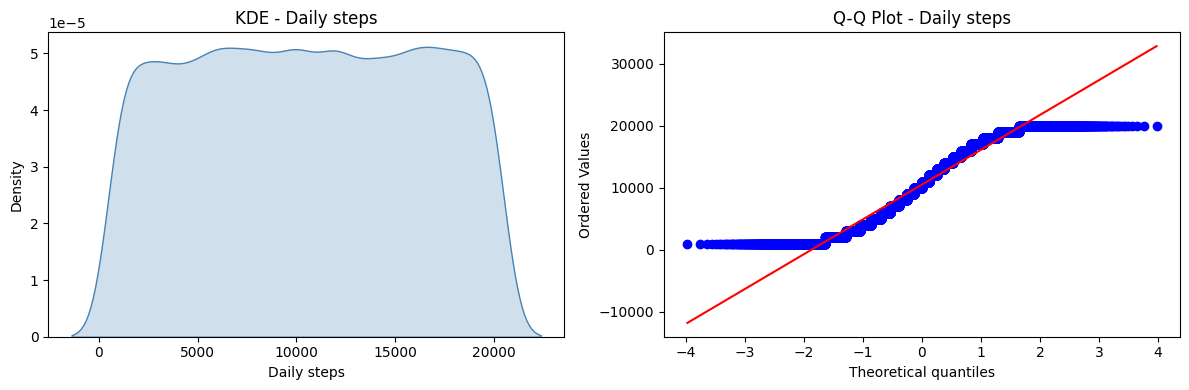


Anderson-Darling Testi - Physical activity
Test İstatistiği: 220.2539
  → %15.0 seviyesinde: NORMAL DEĞİL
  → %10.0 seviyesinde: NORMAL DEĞİL
  → %5.0 seviyesinde: NORMAL DEĞİL
  → %2.5 seviyesinde: NORMAL DEĞİL
  → %1.0 seviyesinde: NORMAL DEĞİL


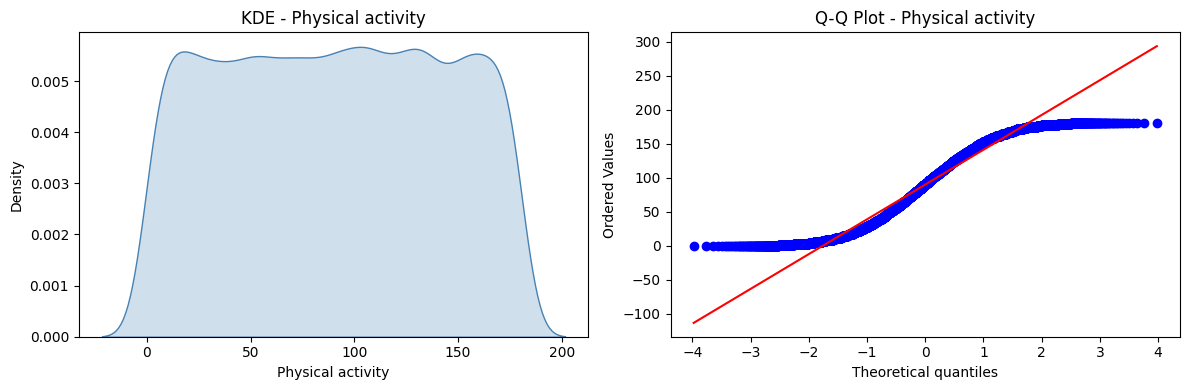


Anderson-Darling Testi - Height
Test İstatistiği: 235.5681
  → %15.0 seviyesinde: NORMAL DEĞİL
  → %10.0 seviyesinde: NORMAL DEĞİL
  → %5.0 seviyesinde: NORMAL DEĞİL
  → %2.5 seviyesinde: NORMAL DEĞİL
  → %1.0 seviyesinde: NORMAL DEĞİL


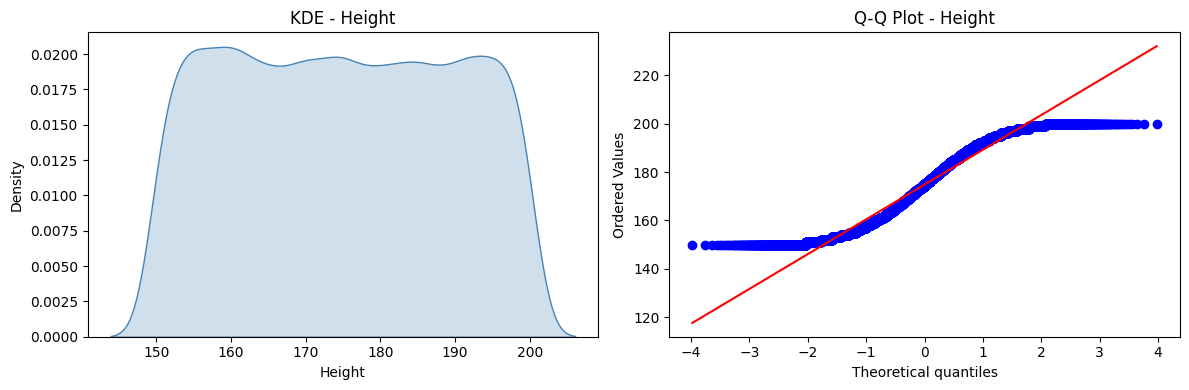


Anderson-Darling Testi - Weight
Test İstatistiği: 233.5121
  → %15.0 seviyesinde: NORMAL DEĞİL
  → %10.0 seviyesinde: NORMAL DEĞİL
  → %5.0 seviyesinde: NORMAL DEĞİL
  → %2.5 seviyesinde: NORMAL DEĞİL
  → %1.0 seviyesinde: NORMAL DEĞİL


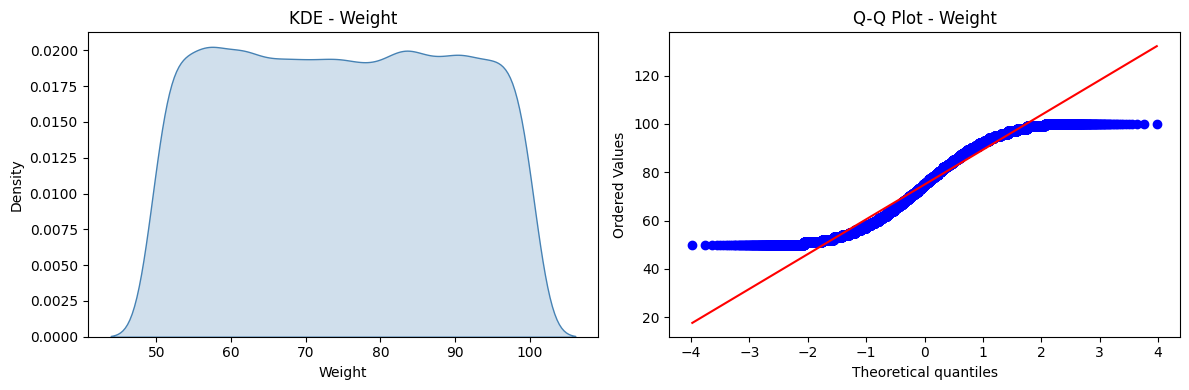


Anderson-Darling Testi - Average screen time
Test İstatistiği: 226.4723
  → %15.0 seviyesinde: NORMAL DEĞİL
  → %10.0 seviyesinde: NORMAL DEĞİL
  → %5.0 seviyesinde: NORMAL DEĞİL
  → %2.5 seviyesinde: NORMAL DEĞİL
  → %1.0 seviyesinde: NORMAL DEĞİL


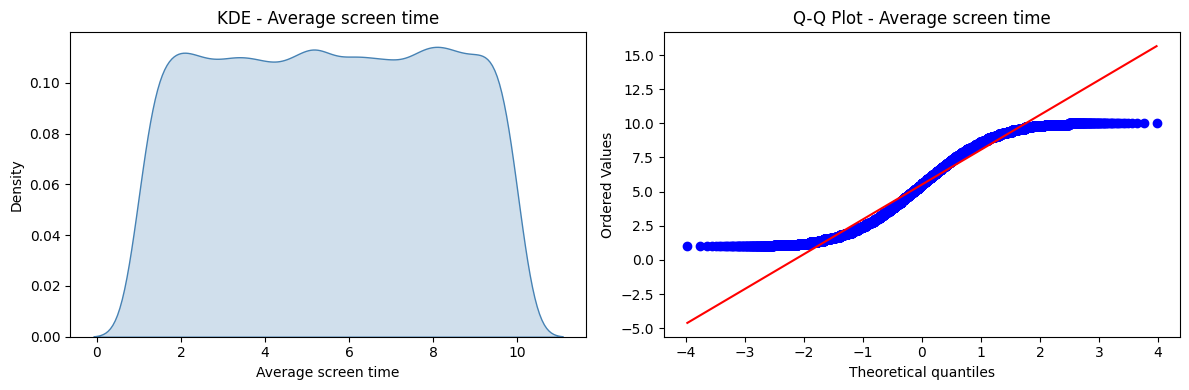

In [29]:
def anderson_kde_qq_all(df):
    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

    for col in numeric_cols:
        data = df[col].dropna()
        result = anderson(data)

        # Anderson çıktısı
        print(f"\nAnderson-Darling Testi - {col}")
        print(f"Test İstatistiği: {result.statistic:.4f}")
        for i in range(len(result.critical_values)):
            sig_level = result.significance_level[i]
            crit_value = result.critical_values[i]
            if result.statistic < crit_value:
                print(f"  → %{sig_level} seviyesinde: NORMAL")
            else:
                print(f"  → %{sig_level} seviyesinde: NORMAL DEĞİL")

        # KDE + Q-Q Plot
        plt.figure(figsize=(12, 4))

        # KDE
        plt.subplot(1, 2, 1)
        sns.kdeplot(data, fill=True, color='steelblue')
        plt.title(f"KDE - {col}")
        plt.xlabel(col)

        # Q-Q Plot
        plt.subplot(1, 2, 2)
        probplot(data, dist="norm", plot=plt)
        plt.title(f"Q-Q Plot - {col}")

        plt.tight_layout()
        plt.show()

anderson_kde_qq_all(df)


In [30]:
def mann_whitney_all(df, target_col="Dry Eye Disease", alpha=0.05):
    # Ensure the target column is excluded from numeric columns
    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
    numeric_cols = numeric_cols.drop(target_col, errors='ignore')
    results = []

    for col in numeric_cols:
        group_1 = df[df[target_col] == "Y"][col].dropna()  # Assuming "Y" represents 1
        group_0 = df[df[target_col] == "N"][col].dropna()  # Assuming "N" represents 0
        
        # En az 2 veri olması gerekir
        if len(group_1) > 1 and len(group_0) > 1:
            stat, p = mannwhitneyu(group_1, group_0, alternative='two-sided')
            results.append({
                "Değişken": col,
                "U İstatistiği": round(stat, 2),
                "p-değeri": round(p, 5),
                "Farklılık": "ANLAMLI" if p < alpha else "YOK"
            })

    # DataFrame olarak göster
    results_df = pd.DataFrame(results).sort_values(by="p-değeri")
    return results_df

mann_results = mann_whitney_all(df)
print(mann_results)

              Değişken  U İstatistiği  p-değeri Farklılık
9  Average screen time     46627880.0   0.00144   ANLAMLI
7               Height     45032773.5   0.36060       YOK
5          Daily steps     45699209.0   0.42356       YOK
3         Stress level     45682957.5   0.43945       YOK
0                  Age     45671544.5   0.46624       YOK
2        Sleep quality     45119711.5   0.48095       YOK
6    Physical activity     45206961.5   0.64104       YOK
8               Weight     45524949.0   0.72534       YOK
4           Heart rate     45271298.0   0.76347       YOK
1       Sleep duration     45342140.0   0.90549       YOK


## Histogram ve Yoğunluk

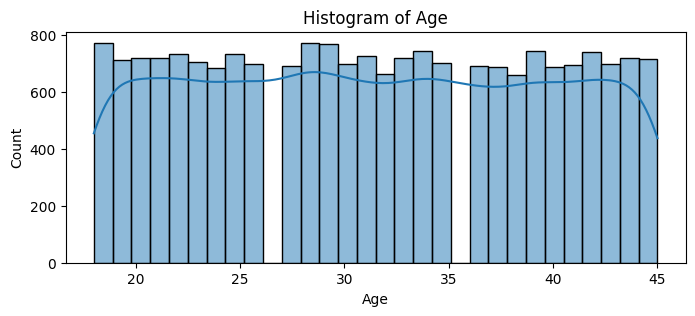

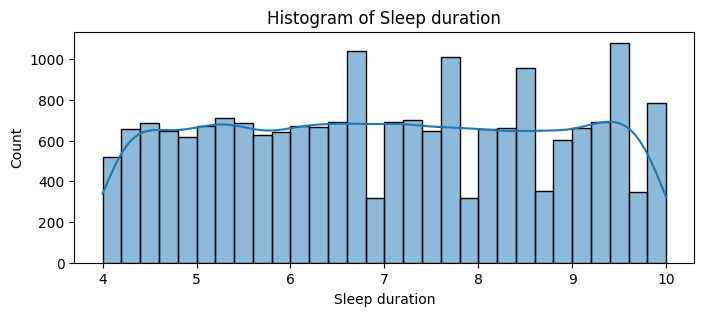

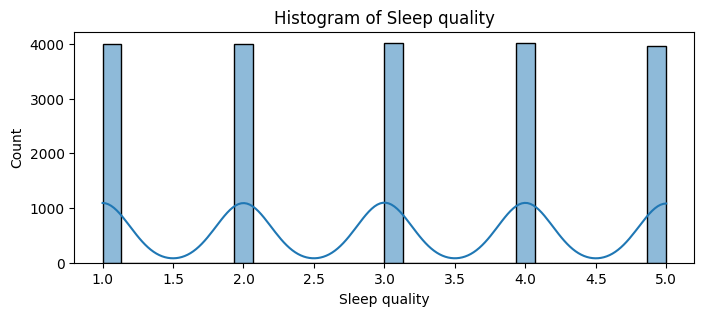

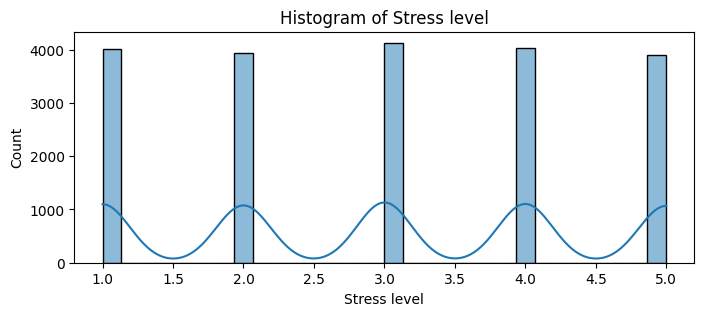

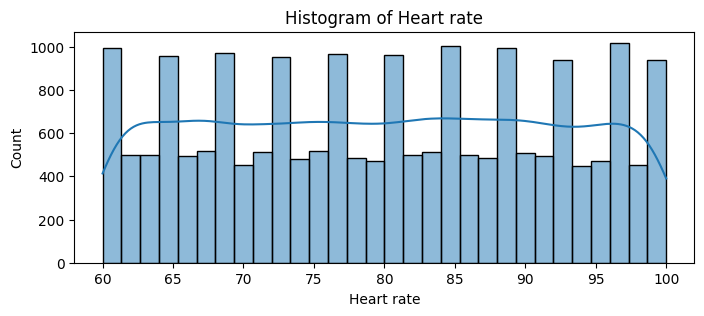

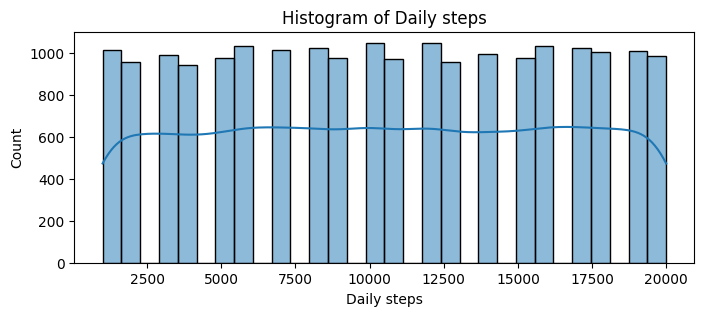

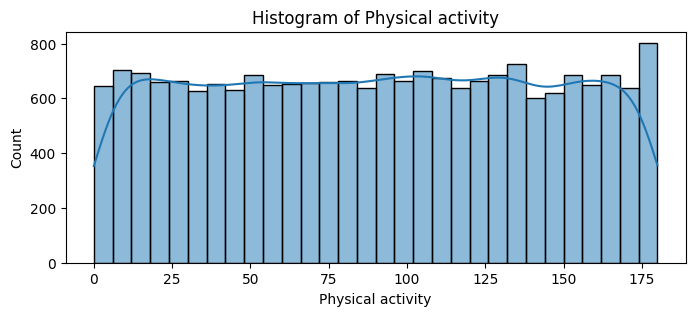

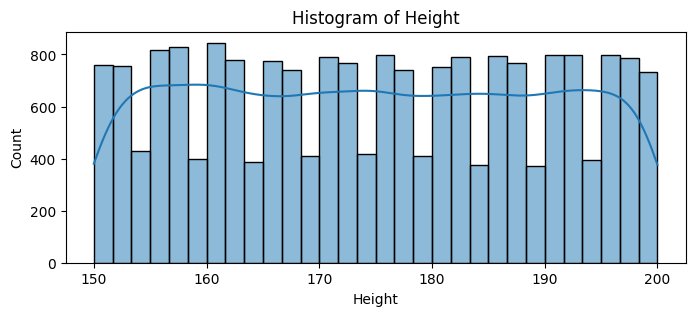

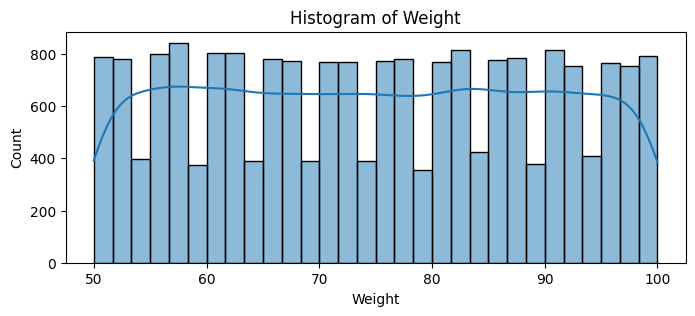

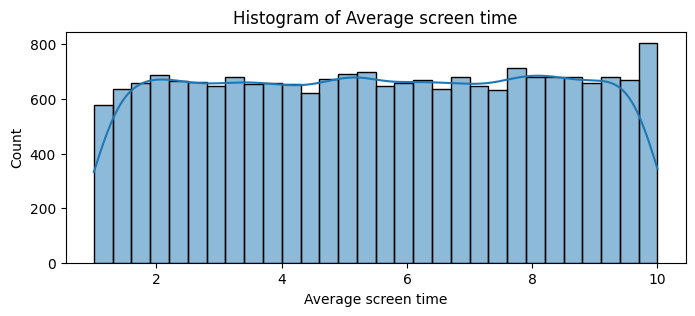

In [32]:
numerical_col=df.select_dtypes(include="number")
for col in numerical_col.columns:
    plt.figure(figsize=(8,3))
    sns.histplot(data=numerical_col[col],kde=True,bins=30)
    plt.title(f"Histogram of {col}")
    plt.show()

## Boxplot

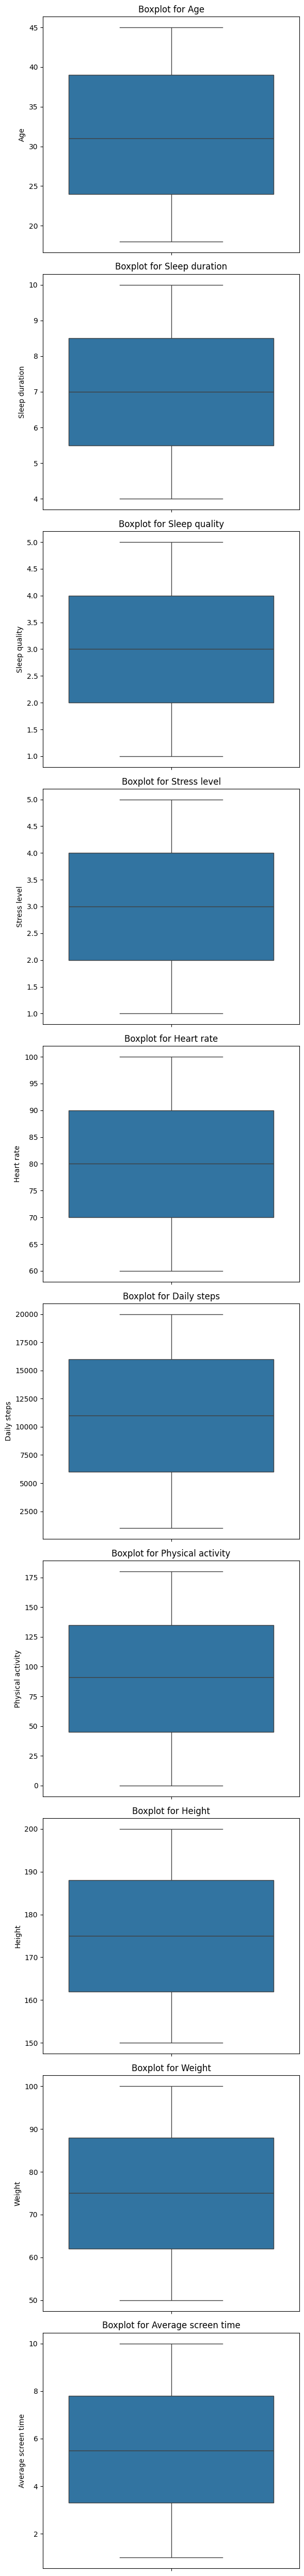

In [34]:
plt.figure(figsize=(6, 5 * len(numerical_col.columns)))  
for i, col in enumerate(numerical_col.columns, 1):
    plt.subplot(len(numerical_col.columns), 1, i) 
    sns.boxplot(data=numerical_col[col])
    plt.title(f"Boxplot for {col}")

plt.tight_layout()
plt.show()

# Çaprazlamalar

## Cinsiyet ve Göz Kuruluğu Hastalığı

### Kadın ve erkeklerde göz kuruluğu hastalığı görülme sıklığını gösterir.

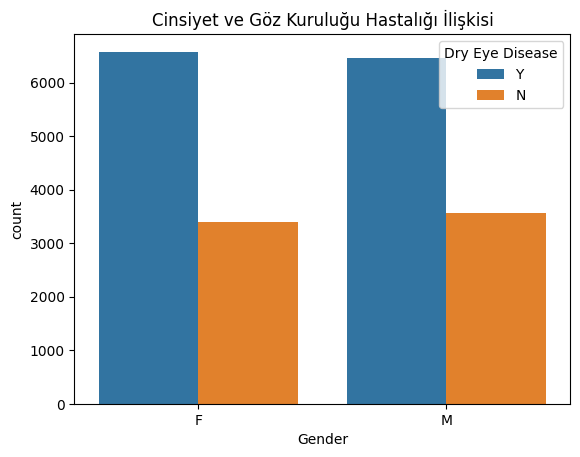

In [38]:
sns.countplot(x="Gender", hue="Dry Eye Disease", data=df)
plt.title("Cinsiyet ve Göz Kuruluğu Hastalığı İlişkisi")
plt.show()


In [39]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["Gender"], df["Dry Eye Disease"])
chi2, p, dof, expected = chi2_contingency(table)
print(f"Chi-Square Test: p-value = {p}")


Chi-Square Test: p-value = 0.021828490579784584


## Ekran Süresi ile Göz Kuruluğu Hastalığı

### Göz kuruluğu hastalığı olan bireylerin ekran süresi daha mı uzun?

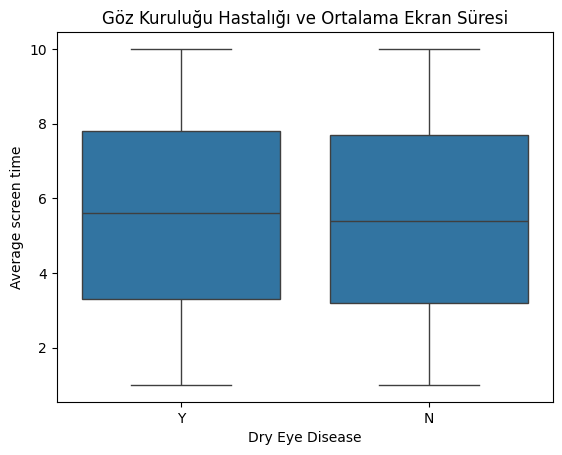

In [42]:
sns.boxplot(x="Dry Eye Disease", y="Average screen time", data=df)
plt.title("Göz Kuruluğu Hastalığı ve Ortalama Ekran Süresi")
plt.show()

In [43]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["Average screen time"], df["Dry Eye Disease"])
chi2, p, dof, expected = chi2_contingency(table)
print(f"Chi-Square Test: p-value = {p}")


Chi-Square Test: p-value = 0.3787346128668557


## Çapraz Tablo

### Bu tablo, cinsiyete göre göz kuruluğu görülme oranlarını yüzde olarak gösterir.

In [46]:
pd.crosstab(df["Gender"], df["Dry Eye Disease"], normalize='index') * 100

Dry Eye Disease,N,Y
Gender,,
F,34.035299,65.964701
M,35.590347,64.409653


## Mavi Işık Filtresi Kullanımı ve Göz Yorgunluğu

### Mavi ışık filtresi kullananlar arasında göz yorgunluğu daha mı az?



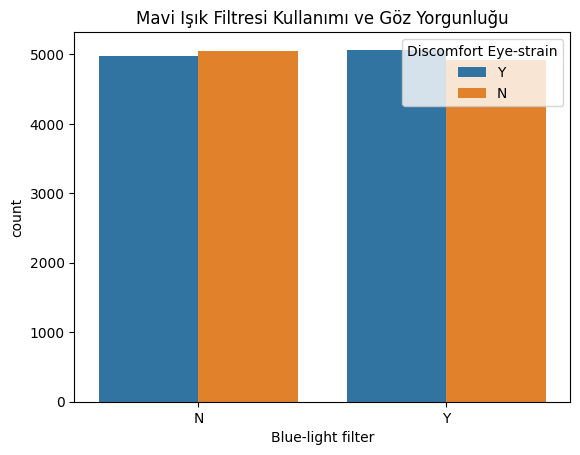

In [49]:
sns.countplot(x="Blue-light filter", hue="Discomfort Eye-strain", data=df)
plt.title("Mavi Işık Filtresi Kullanımı ve Göz Yorgunluğu")
plt.show()

In [50]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["Blue-light filter"], df["Discomfort Eye-strain"])
chi2, p, dof, expected = chi2_contingency(table)
print(f"Chi-Square Test: p-value = {p}")


Chi-Square Test: p-value = 0.11959285919922232


## Cinsiyet, Mavi Işık Filtesi Kullanımı ve Göz Kuruluğu Hastalığı

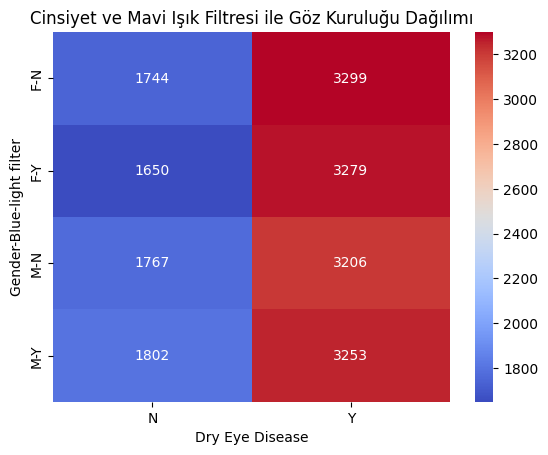

In [52]:
cross = pd.crosstab(index=[df["Gender"], df["Blue-light filter"]], 
                    columns=df["Dry Eye Disease"])
sns.heatmap(cross, annot=True, fmt="d", cmap="coolwarm")
plt.title("Cinsiyet ve Mavi Işık Filtresi ile Göz Kuruluğu Dağılımı")
plt.show()


# Replace

In [54]:
object_col=df.select_dtypes(include="object")
df[object_col.columns] = object_col.replace({"Y": 1, "N": 0}) 

C:\Users\Asus\AppData\Local\Temp\ipykernel_9592\1378147234.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[object_col.columns] = object_col.replace({"Y": 1, "N": 0})


In [55]:
df["Gender"]=df["Gender"].replace({"F":0,"M":1})

C:\Users\Asus\AppData\Local\Temp\ipykernel_9592\4204026420.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Gender"]=df["Gender"].replace({"F":0,"M":1})


In [56]:
le=LabelEncoder()
df["Blood pressure"]=le.fit_transform(df["Blood pressure"])

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       20000 non-null  int64  
 1   Age                          20000 non-null  int64  
 2   Sleep duration               20000 non-null  float64
 3   Sleep quality                20000 non-null  int64  
 4   Stress level                 20000 non-null  int64  
 5   Blood pressure               20000 non-null  int64  
 6   Heart rate                   20000 non-null  int64  
 7   Daily steps                  20000 non-null  int64  
 8   Physical activity            20000 non-null  int64  
 9   Height                       20000 non-null  int64  
 10  Weight                       20000 non-null  int64  
 11  Sleep disorder               20000 non-null  int64  
 12  Wake up during night         20000 non-null  int64  
 13  Feel sleepy duri

# Korelasyon

<Axes: >

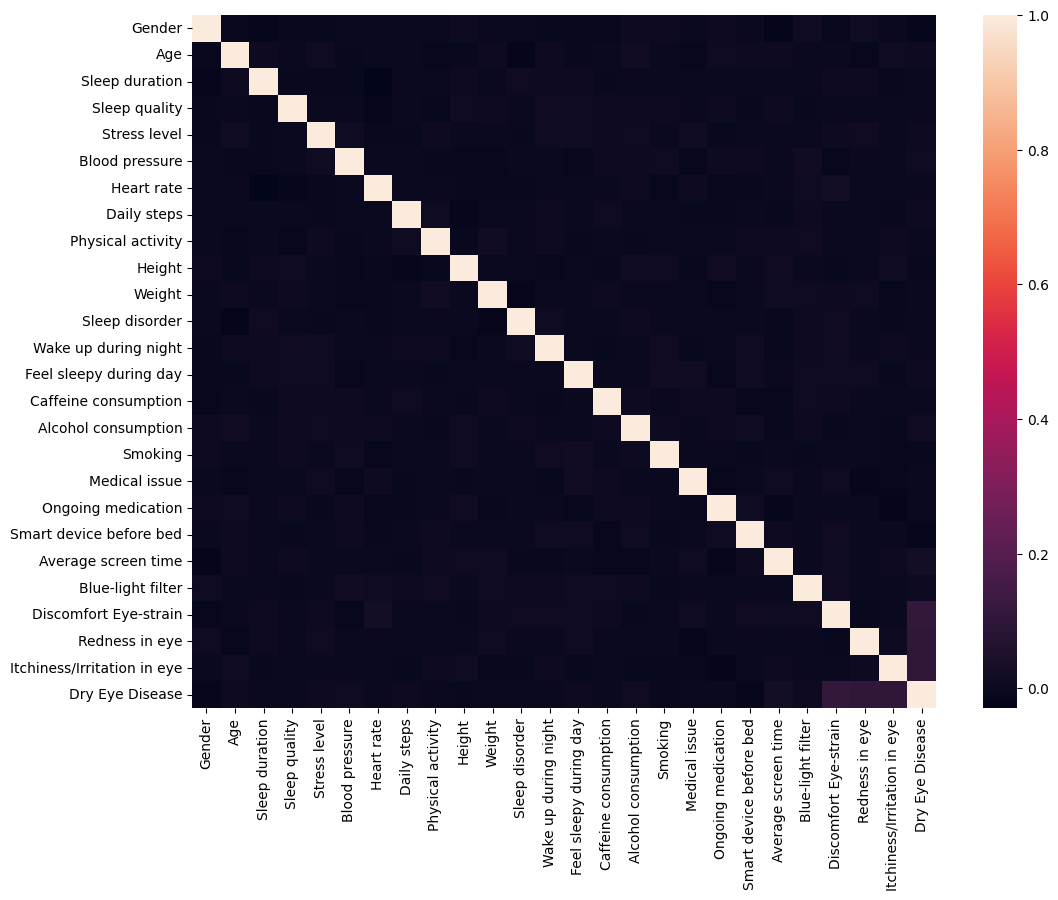

In [59]:
plt.figure(figsize=(12,9))
sns.heatmap(df.corr())

In [60]:
df.corr()

,Gender,Age,Sleep duration,Sleep quality,Stress level,Blood pressure,Heart rate,Daily steps,Physical activity,Height,...,Smoking,Medical issue,Ongoing medication,Smart device before bed,Average screen time,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Dry Eye Disease
Gender,1.000000,-0.007612,-0.014073,-0.005695,-0.006703,-0.004377,-0.000208,-0.000505,-0.000253,0.006942,...,0.005905,-0.001269,0.005377,-0.001701,-0.018310,0.009805,-0.010110,0.007337,-0.000282,-0.016321
Age,-0.007612,1.000000,0.004857,0.002513,0.008379,-0.006273,-0.001196,0.001302,-0.009191,-0.005171,...,-0.003293,-0.010528,0.007507,0.003810,0.003177,-0.002508,-0.001069,-0.010335,0.009893,0.005258
Sleep duration,-0.014073,0.004857,1.000000,-0.006892,-0.006088,-0.005137,-0.029175,0.002823,0.001858,0.005259,...,-0.003637,-0.001804,-0.000208,-0.003081,-0.004208,0.002034,0.006544,0.004315,-0.007170,-0.000874
Sleep quality,-0.005695,0.002513,-0.006892,1.000000,0.000721,-0.000433,-0.014326,-0.003074,-0.010329,0.009380,...,0.006971,0.000297,0.005858,-0.005133,0.004697,-0.007969,0.001459,0.002843,-0.002597,-0.004990
Stress level,-0.006703,0.008379,-0.006088,0.000721,1.000000,0.007032,-0.008332,-0.005978,0.004272,-0.000651,...,0.001165,0.010931,-0.008172,-0.002450,-0.001344,-0.002317,0.003889,0.011989,-0.004114,0.005481
Blood pressure,-0.004377,-0.006273,-0.005137,-0.000433,0.007032,1.000000,-0.004331,-0.001340,-0.006392,-0.012364,...,0.010502,-0.009154,0.003406,0.003655,-0.000365,0.016279,-0.009773,0.001880,-0.000066,0.010954
Heart rate,-0.000208,-0.001196,-0.029175,-0.014326,-0.008332,-0.004331,1.000000,-0.001899,0.001334,-0.005229,...,-0.010954,0.003898,-0.012871,-0.007891,0.002467,0.008719,0.019235,-0.004331,-0.000182,-0.002083
Daily steps,-0.000505,0.001302,0.002823,-0.003074,-0.005978,-0.001340,-0.001899,1.000000,0.008413,-0.016801,...,0.001810,-0.006352,-0.007528,-0.000237,-0.008670,0.006512,0.000107,0.000735,-0.008069,0.005664
Physical activity,-0.000253,-0.009191,0.001858,-0.010329,0.004272,-0.006392,0.001334,0.008413,1.000000,-0.005989,...,-0.000228,-0.000766,0.002152,0.004275,0.006469,0.012624,0.001386,0.000689,0.004153,-0.003289
Height,0.006942,-0.005171,0.005259,0.009380,-0.000651,-0.012364,-0.005229,-0.016801,-0.005989,1.000000,...,0.008979,-0.006909,0.012976,-0.004522,0.012817,-0.002263,-0.008730,0.000840,0.007321,-0.006437


# PCA

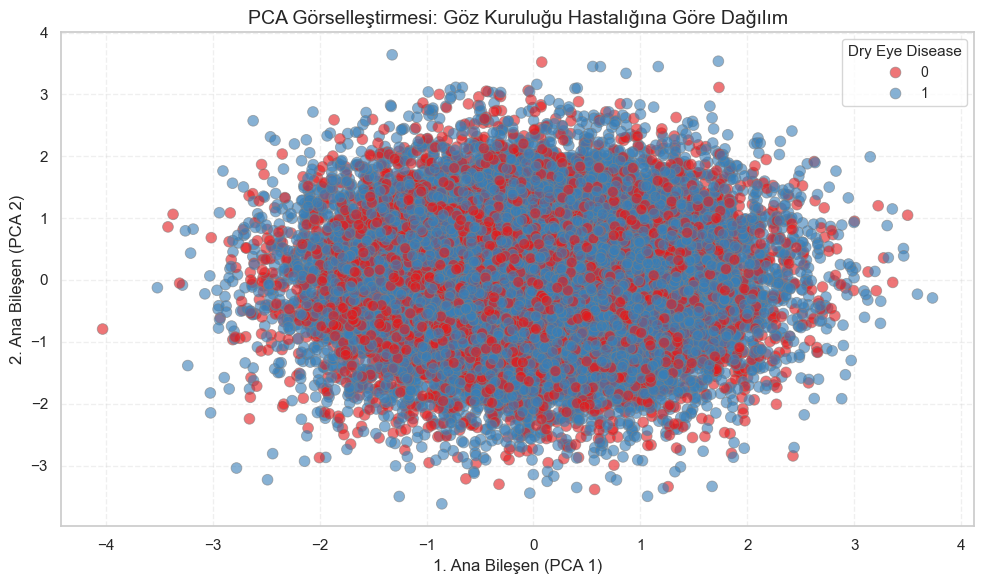


İlk 2 PCA bileşeni toplam varyansın %8.47 kadarını açıklamaktadır.


In [64]:
X = df.drop("Dry Eye Disease", axis=1)
X = X.select_dtypes(include=["int64", "float64"]).dropna()

y = df.loc[X.index, "Dry Eye Disease"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=["PCA 1", "PCA 2"])
pca_df["Dry Eye Disease"] = y.values

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x="PCA 1",
    y="PCA 2",
    hue="Dry Eye Disease",
    palette="Set1",
    s=60,              
    edgecolor="gray",  
    alpha=0.6
)          

plt.title("PCA Görselleştirmesi: Göz Kuruluğu Hastalığına Göre Dağılım", fontsize=14)
plt.xlabel("1. Ana Bileşen (PCA 1)", fontsize=12)
plt.ylabel("2. Ana Bileşen (PCA 2)", fontsize=12)
plt.legend(title="Dry Eye Disease", loc="best", fontsize=10, title_fontsize=11)

plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

explained_variance = pca.explained_variance_ratio_.sum() * 100
print(f"\nİlk 2 PCA bileşeni toplam varyansın %{explained_variance:.2f} kadarını açıklamaktadır.")

In [65]:
x=df.drop(["Dry Eye Disease"],axis=1)
y=df["Dry Eye Disease"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
ss=StandardScaler()
x_train=ss.fit_transform(x_train)
x_test=ss.transform(x_test)

# Model

In [67]:
models = {
    "Random Forest Classifier": RandomForestClassifier(),
    "Decision Tree Classifier": DecisionTreeClassifier(),
    "AdaBoost Classifier": AdaBoostClassifier(),
    "Gradient Boosting Classifier": GradientBoostingClassifier(),
    "Bagging Classifier": BaggingClassifier(),
    "Extra Trees Classifier": ExtraTreesClassifier(),
    "Logistic Regression": LogisticRegression(),
    "Ridge Classifier": RidgeClassifier(),
    "Perceptron": Perceptron(),
    "SGD Classifier": SGDClassifier(),
    "Gaussian Naive Bayes": GaussianNB(),
    "Bernoulli Naive Bayes": BernoulliNB(),
    "Support Vector Classifier (SVC)": SVC(),
    "Nu-Support Vector Classifier": NuSVC(),
    "Linear SVC": LinearSVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
    "Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis()
}

In [ ]:
# Model performanslarının çıktısı
for name, model in models.items():
    try:
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        print(f"\n{name}")
        print(classification_report(y_test, y_pred))
    except Exception as e:
        print(f"{name} modelinde hata: {e}")


Random Forest Classifier
              precision    recall  f1-score   support

           0       0.62      0.23      0.34      1646
           1       0.71      0.93      0.81      3354

    accuracy                           0.70      5000
   macro avg       0.67      0.58      0.57      5000
weighted avg       0.68      0.70      0.65      5000


Decision Tree Classifier
              precision    recall  f1-score   support

           0       0.35      0.39      0.37      1646
           1       0.68      0.64      0.66      3354

    accuracy                           0.56      5000
   macro avg       0.52      0.52      0.52      5000
weighted avg       0.58      0.56      0.57      5000


AdaBoost Classifier
              precision    recall  f1-score   support

           0       0.63      0.17      0.26      1646
           1       0.70      0.95      0.81      3354

    accuracy                           0.69      5000
   macro avg       0.66      0.56      0.54      5000
w

In [ ]:
metrics = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall':[]
}
for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall=recall_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    metrics['Model'].append(name)
    metrics['Accuracy'].append(acc * 100)
    metrics['Precision'].append(precision * 100)
    metrics['Recall'].append(recall * 100)
    print(f"Model: {name}")
    print(f"Accuracy: {acc*100}")
    print(f"Precision: {precision*100}")
    print(f"Recall: {recall*100}")
    print(f"F1-score: {f1*100}")
    print("-" * 30)

In [ ]:
num_models = len(models)
rows = (num_models // 3) + (num_models % 3 > 0)
plt.figure(figsize=(15, 5 * rows))

for i, (name, model) in enumerate(models.items(), 1):
    model.fit(x_train, y_train)

    try:
        if hasattr(model, "predict_proba"):  
            y_prob = model.predict_proba(x_test)[:, 1]
        else:
            y_prob = model.decision_function(x_test)
            # Normalize: decision_function genelde min/max dışında kalabilir
            y_prob = (y_prob - np.min(y_prob)) / (np.max(y_prob) - np.min(y_prob))

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_score = auc(fpr, tpr)

        plt.subplot(rows, 3, i)
        plt.plot(fpr, tpr, label=f"AUC: {auc_score:.2f}")
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {name}")
        plt.legend()
    
    except Exception as e:
        print(f"{name} için ROC çizilemedi. Hata: {e}")

plt.suptitle("ROC Curve for Different Models", fontsize=16)
plt.subplots_adjust(top=0.9)  # Adjust the top to make room for the title
plt.tight_layout(rect=[0, 0.03, 1, 0.97])  # Adjust layout to make room for the title

plt.show()


In [ ]:
plt.figure(figsize=(12,8))
results=pd.DataFrame(metrics)
sns.barplot(x="Accuracy",y="Model",data=results,color="lightblue")
plt.title("Model Accuracy")
plt.show()

In [ ]:
import pandas as pd

# 1. Eğitim/test ayrımı
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

# 2. Veriyi ölçekle
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 3. Seçilen modeller
models = {
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Gaussian Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier()
}

# 4. Model performanslarını hesapla
results = []

plt.figure(figsize=(15, 4))

for i, (name, model) in enumerate(models.items(), 1):
    # Not: Naive Bayes için orijinal veriler kullanılmalı, çünkü Gauss dağılımı varsayar
    if name == "Gaussian Naive Bayes":
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        y_prob = model.predict_proba(x_test)[:, 1]
    else:
        model.fit(x_train_scaled, y_train)
        y_pred = model.predict(x_test_scaled)
        y_prob = model.predict_proba(x_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "AUC": auc_score
    })
    
    # ROC grafiği çiz
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.subplot(1, 4, i)
    plt.plot(fpr, tpr, label=f"AUC: {auc_score:.2f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"ROC - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

plt.tight_layout()
plt.show()

# 5. Sonuçları göster
results_df = pd.DataFrame(results)
print("\nModel Performansları:")
print(results_df.sort_values("AUC", ascending=False).round(3))


In [ ]:
# Kullanıcıdan veri alma ve tahmin yapma
def get_user_input():
    print("Lütfen aşağıdaki 25 soruyu cevaplayınız (Evet=1, Hayır=0).")
    
    user_data = {}

    user_data["Gender"] = int(input("1) Cinsiyetiniz (Kadın:0 / Erkek:1): "))
    user_data["Age"] = int(input("2) Yaşınız: "))
    user_data["Sleep duration"] = float(input("3) Günde ortalama kaç saat uyuyorsunuz?: "))
    user_data["Sleep quality"] = int(input("4) Uyku kalitenizi 1–5 arasında puanlayın: "))
    user_data["Stress level"] = int(input("5) Stres düzeyiniz (1–10 arası): "))
    user_data["Blood pressure"] = int(input("6) Tansiyon durumunuz (0=Düşük, 1=Normal, 2=Yüksek): "))
    user_data["Heart rate"] = int(input("7) Ortalama kalp atış hızınız: "))
    user_data["Daily steps"] = int(input("8) Günlük ortalama attığınız adım sayısı: "))
    user_data["Physical activity"] = int(input("9) Düzenli fiziksel aktivite yapıyor musunuz? (1/0): "))
    user_data["Height"] = float(input("10) Boyunuz (cm): "))
    user_data["Weight"] = float(input("11) Kilonuz (kg): "))
    user_data["Sleep disorder"] = int(input("12) Uyku bozukluğunuz var mı? (1/0): "))
    user_data["Wake up during night"] = int(input("13) Gece sık uyanır mısınız? (1/0): "))
    user_data["Feel sleepy during day"] = int(input("14) Gündüz uykulu hisseder misiniz? (1/0): "))
    user_data["Caffeine consumption"] = int(input("15) Kafein (çay/kahve) tüketiyor musunuz? (1/0): "))
    user_data["Alcohol consumption"] = int(input("16) Alkol tüketiyor musunuz? (1/0): "))
    user_data["Smoking"] = int(input("17) Sigara kullanıyor musunuz? (1/0): "))
    user_data["Medical issue"] = int(input("18) Başka bir sağlık sorununuz var mı? (1/0): "))
    user_data["Ongoing medication"] = int(input("19) Düzenli ilaç kullanıyor musunuz? (1/0): "))
    user_data["Smart device before bed"] = int(input("20) Uyumadan önce telefon/tablet kullanıyor musunuz? (1/0): "))
    user_data["Average screen time"] = float(input("21) Günlük ekran süreniz (saat): "))
    user_data["Blue-light filter"] = int(input("22) Mavi ışık filtresi kullanıyor musunuz? (1/0): "))
    user_data["Discomfort Eye-strain"] = int(input("23) Göz yorgunluğu / rahatsızlık hissediyor musunuz? (1/0): "))
    user_data["Redness in eye"] = int(input("24) Göz kızarıklığı yaşar mısınız? (1/0): "))
    user_data["Itchiness/Irritation in eye"] = int(input("25) Göz kaşıntısı / batma olur mu? (1/0): "))

    return pd.DataFrame([user_data])

def predict_disease(user_df, scaler, models):
    user_scaled = scaler.transform(user_df)

    gb_pred = models["Gradient Boosting"].predict(user_scaled)[0]
    log_pred = models["Logistic Regression"].predict(user_scaled)[0]
    nb_pred = models["Gaussian Naive Bayes"].predict(user_df)[0]
    rf_pred = models["Random Forest"].predict(user_scaled)[0]

    print("\nTahmin Sonuçları")
    print(f"Gradient Boosting: {'HASTA' if gb_pred else 'SAĞLIKLI'}")
    print(f"Logistic Regression: {'HASTA' if log_pred else 'SAĞLIKLI'}")
    print(f"Naive Bayes: {'HASTA' if nb_pred else 'SAĞLIKLI'}")
    print(f"Random Forest: {'HASTA' if rf_pred else 'SAĞLIKLI'}")

    votes = gb_pred + log_pred + nb_pred + rf_pred
    print("\nOrtak Karar:")
    if votes >= 3:
        print("SONUÇ: KULLANICI HASTA")
    elif votes == 2:
        print("SONUÇ: KULLANICI MUHTEMELEN HASTA")
    else:
        print("SONUÇ: KULLANICI SAĞLIKLI")


user_df = get_user_input()
predict_disease(user_df, scaler, models)

